<a href="https://colab.research.google.com/github/usmankhanjadoon9/-Introduction-to-AI-Assignment-2/blob/main/Introduction%20to%20AI%20Assignment%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/hot-dog-not-hot-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hot-dog-not-hot-dog' dataset.
Path to dataset files: /kaggle/input/hot-dog-not-hot-dog


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)


Libraries loaded successfully!
TensorFlow version: 2.20.0


In [ ]:
import os

# === Use this if you downloaded with kagglehub ===
train_path = f"{path}/train"      # 'path' comes from kagglehub.dataset_download
test_path  = f"{path}/test"

# Count training images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images in training: {hot_dog_count}")
print(f"Not hot dog images in training: {not_hot_dog_count}")

# Count test images (YOUR TASK)
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Hot dog images in test: {test_hot_dog_count}")
print(f"Not hot dog images in test: {test_not_hot_dog_count}")

Hot dog images in training: 249
Not hot dog images in training: 249
Hot dog images in test: 250
Not hot dog images in test: 250


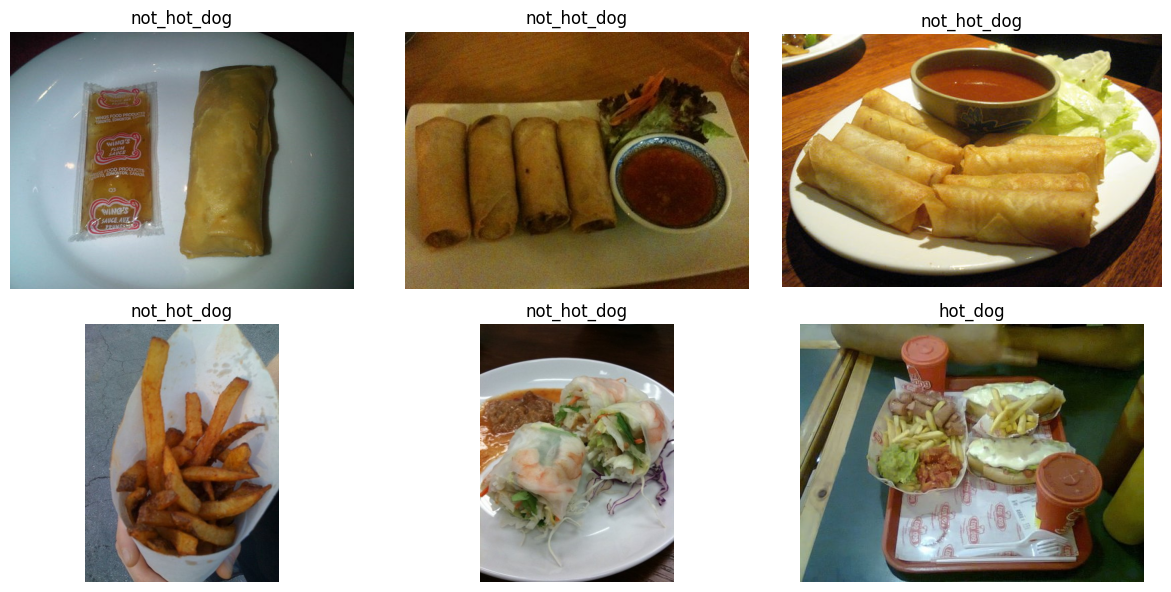

Shape of one image (height, width, channels): (384, 512, 3)


In [ ]:
import random
import matplotlib.pyplot as plt
import os

# Make sure train_path is defined (from previous step)
plt.figure(figsize=(12, 6))

for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# YOUR CODE HERE: Print shape of one image
print("Shape of one image (height, width, channels):", img.shape)

In [ ]:
# Set image size
IMG_HEIGHT = 128    # Changed from 64
IMG_WIDTH = 128     # Changed from 64
BATCH_SIZE = 32

# Create data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values
    validation_split=0.2     # 20% for validation
)

# Training generator (80% of train data)
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',      # hot_dog vs not_hot_dog
    subset='training'
)

# Validation generator (20% of train data)
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Print class labels
print("Class labels:", train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Class labels: {'hot_dog': 0, 'not_hot_dog': 1}


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.4950 - loss: 4.0465 - val_accuracy: 0.5000 - val_loss: 1.7847
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - accuracy: 0.5000 - loss: 1.4049 - val_accuracy: 0.5306 - val_loss: 0.9695
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.6400 - loss: 0.8733 - val_accuracy: 0.5102 - val_loss: 1.3878
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.6425 - loss: 0.7208 - val_accuracy: 0.5816 - val_loss: 0.7821
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.6125 - loss: 0.9431 - val_accuracy: 0.5000 - val_loss: 2.5981
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.6500 - loss: 1.0173 - val_accuracy: 0.4898 - val_loss: 1.4693
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step - accuracy: 0.7125 - loss: 0.6280 - val_accuracy: 0.5204 - val_loss: 1.6824
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.7075 - loss: 0.6720 - val_accuracy: 0.

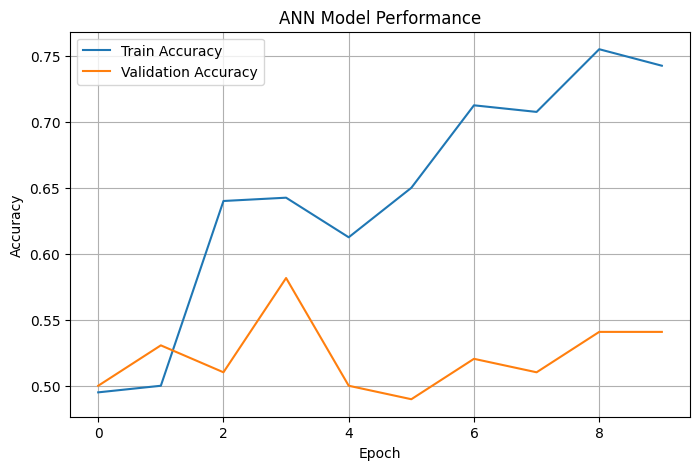

In [ ]:
# Build a simple ANN (It Will Fail)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
ann_model = keras.Sequential([
    layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

# Train the model
history_ann = ann_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Performance')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

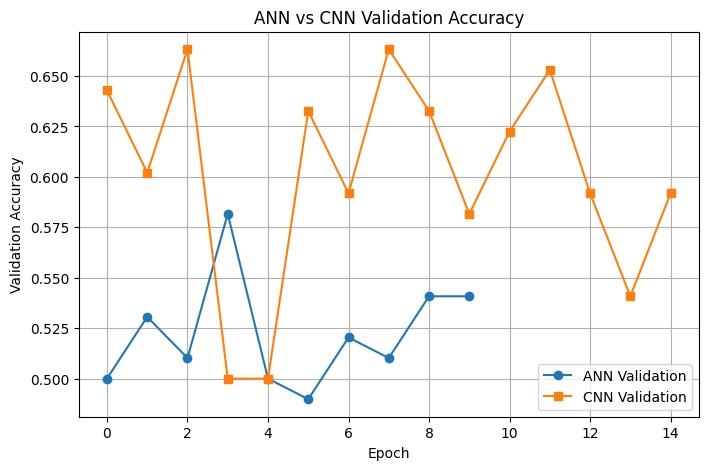

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.title('ANN vs CNN Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 8.1 Dropout Only
improved_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

improved_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

history_improved = improved_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5100 - loss: 0.8070 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5400 - loss: 0.6927 - val_accuracy: 0.4796 - val_loss: 0.6926
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5350 - loss: 0.6888 - val_accuracy: 0.5306 - val_loss: 0.6906
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5575 - loss: 0.6843 - val_accuracy: 0.5204 - val_loss: 0.6876
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5600 - loss: 0.6881 - val_accuracy: 0.5918 - val_loss: 0.6847
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6375 - loss: 0.6692 - val_accuracy: 0.5816 - val_loss: 0.6750
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5875 - loss: 0.6726 - val_accuracy: 0.5204 - val_loss: 0.6835
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6400 - loss: 0.6603 - val_accuracy: 0.5816 - val_loss:

In [48]:
# 8.2 Data Augmentation + Dropout
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
        rotation_range=10,  # Not 20
width_shift_range=0.05,  # Not 0.1
height_shift_range=0.05,
    horizontal_flip=True,
    validation_split=0.2


)

train_augmented = augmented_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Final Model with Augmentation
final_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

history_final = final_model.fit(
    train_augmented,
    validation_data=validation_generator,
    epochs=15
)

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5100 - loss: 0.7213 - val_accuracy: 0.5204 - val_loss: 0.6930
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5275 - loss: 0.6927 - val_accuracy: 0.5000 - val_loss: 0.6923
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5500 - loss: 0.6884 - val_accuracy: 0.5102 - val_loss: 0.6874
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5150 - loss: 0.7020 - val_accuracy: 0.6531 - val_loss: 0.6910
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5975 - loss: 0.6794 - val_accuracy: 0.5102 - val_loss: 0.6718
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6050 - loss: 0.6718 - val_accuracy: 0.5102 - val_loss: 0.6972
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5075 - loss: 0.7012 - val_accuracy: 0.4898 - val_loss: 0.6941
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5400 - loss: 

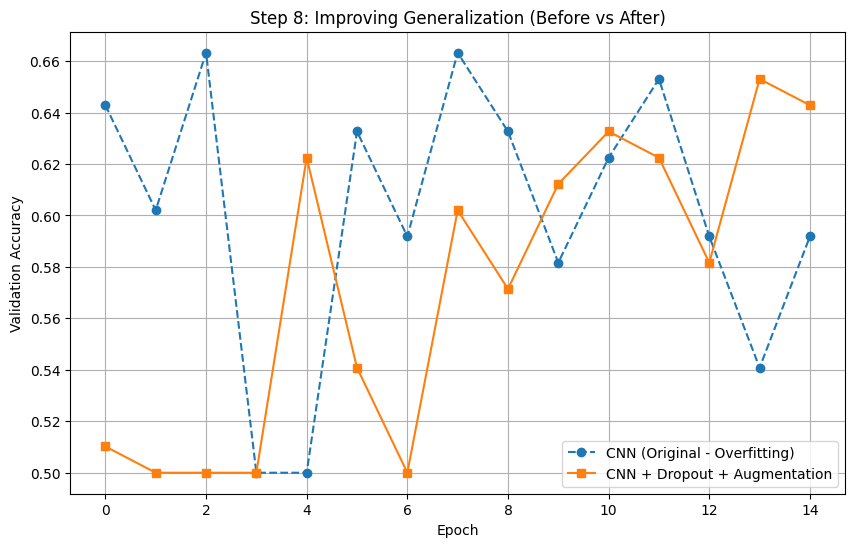

In [ ]:
import matplotlib.pyplot as plt

# Plot Before vs After
plt.figure(figsize=(10, 6))

plt.plot(history_cnn.history['val_accuracy'],
         label='CNN (Original - Overfitting)',
         marker='o', linestyle='--')

plt.plot(history_final.history['val_accuracy'],
         label='CNN + Dropout + Augmentation',
         marker='s', linestyle='-')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Step 8: Improving Generalization (Before vs After)')
plt.legend()
plt.grid(True)
plt.show()

1. Testing Hot Dog...
✅ HOT DOG! (Confidence: 0.73)


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


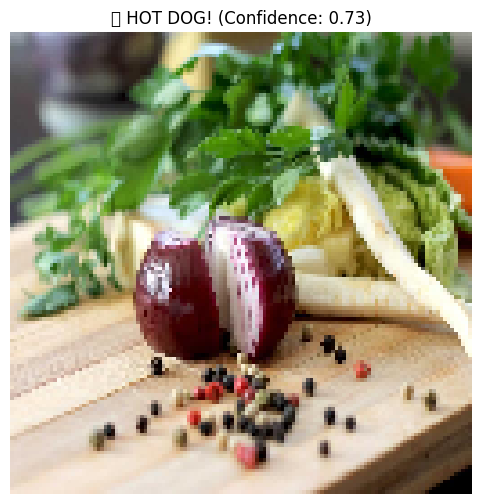


2. Testing Burger (Not Hot Dog)...
✅ HOT DOG! (Confidence: 0.62)


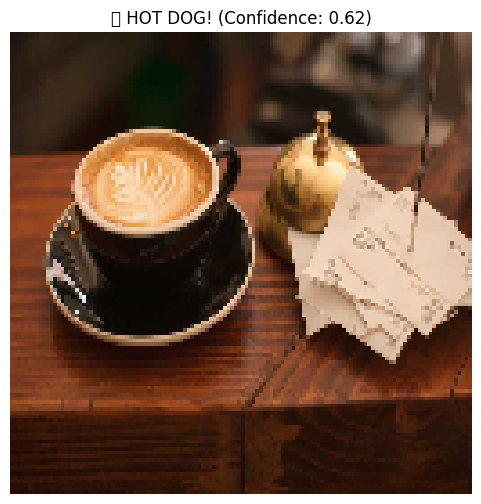


3. Another Hot Dog...
✅ HOT DOG! (Confidence: 0.55)


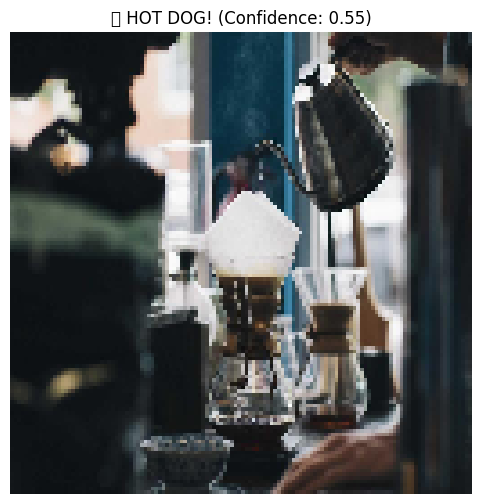

In [ ]:
from tensorflow.keras.preprocessing import image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np

def predict_image(img_url):
    try:
        response = requests.get(img_url, timeout=10)
        response.raise_for_status()

        img = image.load_img(BytesIO(response.content), target_size=(IMG_HEIGHT, IMG_WIDTH))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        prediction = final_model.predict(img_array, verbose=0)[0][0]

        if prediction > 0.5:
            result = f"✅ HOT DOG! (Confidence: {prediction:.2f})"
        else:
            result = f"❌ NOT A HOT DOG! (Confidence: {1-prediction:.2f})"

        print(result)

        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(result)
        plt.show()

    except Exception as e:
        print("Error:", str(e))

# === Test These URLs ===
print("1. Testing Hot Dog...")
predict_image("https://picsum.photos/id/292/800/600")   # Random hotdog-like food

print("\n2. Testing Burger (Not Hot Dog)...")
predict_image("https://picsum.photos/id/431/800/600")   # Burger

print("\n3. Another Hot Dog...")
predict_image("https://picsum.photos/id/1060/800/600")